In [14]:
import pandas as pd
import os


In [15]:
path = ("../data/traffic.htm/")
os.path.exists(path)

True

In [16]:
df = pd.read_html("../data/traffic.htm/N1.traffic.htm")

In [17]:
tables = pd.read_html("../data/traffic.htm/N102.traffic.htm", encoding="iso-8859-1")
print(len(tables))  # how many tables were found?
for i, t in enumerate(tables):
    print(i, t.shape, t.iloc[0, 0])  # index, size, first cell

5
0 (1, 2) nan
1 (4, 4) nan
2 (19, 26) nan
3 (17, 26) nan
4 (13, 26) List of links of N102 (  what is a link  )


In [18]:
tables = pd.read_html("../data/traffic.htm/N102.traffic.htm", encoding="iso-8859-1")

df = tables[4].iloc[3:].reset_index(drop=True)  # skip the 3 header rows

df.columns = [
    "link_no", "name",
    "start_lrp", "start_offset", "start_chainage",
    "end_lrp", "end_offset", "end_chainage",
    "length_km",
    "heavy_truck", "medium_truck", "small_truck",
    "large_bus", "medium_bus", "micro_bus",
    "utility", "car", "auto_rickshaw", "motorcycle", "bicycle",
    "cycle_rickshaw", "cart",
    "motorized_total", "non_motorized_total",
    "total_aadt", "aadt"
]
df

,link_no,name,start_lrp,start_offset,start_chainage,end_lrp,end_offset,end_chainage,length_km,heavy_truck,...,car,auto_rickshaw,motorcycle,bicycle,cycle_rickshaw,cart,motorized_total,non_motorized_total,total_aadt,aadt
0,N102-1,Mainamati-Kangsanagar (Intersection with Z1219),LRPS,0,0,LRP009,1110,10.206,10.206,231.0,...,164.0,5450.0,621.0,196.0,413.0,0.0,9099.0,609.0,9708.0,9708.0
1,N102-2,Kangsanagar (Int with Z1219)-Debidduar (Int wi...,LRP009,1110,10.206,LRP018,2570,20.658,10.452,231.0,...,164.0,5450.0,621.0,196.0,413.0,0.0,9099.0,609.0,9708.0,9708.0
2,N102-3,Debiduar (Int with Z1008)- Companiganj (Int wi...,LRP018,2570,20.658,LRP024,1242,25.473,4.815,231.0,...,164.0,5450.0,621.0,196.0,413.0,0.0,9099.0,609.0,9708.0,9708.0
3,N102-4,Companiganj (Int with Z1205) - Mirpur (Int wit...,LRP024,1242,25.473,LRP038,408,38.866,13.393,346.0,...,231.0,2525.0,483.0,124.0,507.0,0.0,6046.0,631.0,6677.0,6677.0
4,N102-5,Mirpur (Int with Z1041)- Kuti (Int with Z1201),LRP038,408,38.866,LRP042,1928,44.427,5.561,346.0,...,231.0,2525.0,483.0,124.0,507.0,0.0,6046.0,631.0,6677.0,6677.0
5,N102-6,Kuti (Int with Z1201)- Dharkhar (Int with Z1202),LRP042,1928,44.427,LRP055,1143,56.883,12.456,346.0,...,231.0,2525.0,483.0,124.0,507.0,0.0,6046.0,631.0,6677.0,6677.0
6,N102-7,Dharkhar (Int with Z1202)-Sultanpur (Int with ...,LRP055,1143,56.883,LRP062,169,63.061,6.178,346.0,...,231.0,2525.0,483.0,124.0,507.0,0.0,6046.0,631.0,6677.0,6677.0
7,N102-8,Sultanpur (Int with Z1216)-Kuatali(Int. with N...,LRP062,169,63.061,LRP070,419,71.456,8.395,98.0,...,512.0,5591.0,858.0,209.0,1041.0,0.0,11521.0,1250.0,12771.0,12771.0
8,N102-9,Kuatali(Int. with N103)-Gathuria(Int. with N103),LRP070,419,71.456,LRP070,6234,77.271,5.815,98.0,...,512.0,5591.0,858.0,209.0,1041.0,0.0,11521.0,1250.0,12771.0,12771.0
9,N102-10,"Gathuria(Int. with N103)-Sarail(Kathihat, int....",LRP070,6234,77.271,LRPE,0,83.382,6.111,98.0,...,512.0,5591.0,858.0,209.0,1041.0,0.0,11521.0,1250.0,12771.0,12771.0


In [19]:
col_names = [
    "link_no", "name",
    "start_lrp", "start_offset", "start_chainage",
    "end_lrp", "end_offset", "end_chainage",
    "length_km",
    "heavy_truck", "medium_truck", "small_truck",
    "large_bus", "medium_bus", "micro_bus",
    "utility", "car", "auto_rickshaw", "motorcycle", "bicycle",
    "cycle_rickshaw", "cart",
    "motorized_total", "non_motorized_total",
    "total_aadt", "aadt"
]

data_dir = "../data/traffic.htm/"
all_dfs = []

for filename in os.listdir(data_dir):
    if filename.endswith(".traffic.htm"):
        filepath = os.path.join(data_dir, filename)
        try:
            tables = pd.read_html(filepath, encoding="iso-8859-1", match="List of links")
            df = tables[0].copy()
            df.columns = col_names
            # Keep only rows where link_no looks like an actual link, e.g. "N102-1"
            df = df[df["link_no"].str.strip().str.match(r"^[A-Z]+\d+-\d+", na=False)]
            df = df.reset_index(drop=True)
            df["road"] = filename.replace(".traffic.htm", "")
            all_dfs.append(df)
        except Exception as e:
            print(f"Skipped {filename}: {e}")

combined = pd.concat(all_dfs, ignore_index=True)
combined


,link_no,name,start_lrp,start_offset,start_chainage,end_lrp,end_offset,end_chainage,length_km,heavy_truck,...,auto_rickshaw,motorcycle,bicycle,cycle_rickshaw,cart,motorized_total,non_motorized_total,total_aadt,aadt,road
0,N501-1,Diabari More-Birulia (Int.with N511),LRPS,0,0,LRP006,660,6.611,6.611,72.0,...,1443.0,988.0,165.0,355.0,3.0,10823.0,523.0,11346.0,11346.0,N501
1,N501-2,Birulia (Int.with N511)-Dhour (Int.with N302),LRP006,660,6.611,LRPE,0,11.942,5.331,72.0,...,1443.0,988.0,165.0,355.0,3.0,10823.0,523.0,11346.0,11346.0,N501
2,N604-1,Pabna (Central Bus Stand)-Pabna (Anonta More) ...,LRPS,0,0,LRPS,1990,1.99,1.990,21.0,...,4187.0,2698.0,2110.0,2172.0,2.0,8304.0,4284.0,12588.0,12588.0,N604
3,N604-2,Pabna (Anonta More)int.with R601 -Police Line ...,LRPS,1990,1.99,LRPS,3386,3.386,1.396,21.0,...,4187.0,2698.0,2110.0,2172.0,2.0,8304.0,4284.0,12588.0,12588.0,N604
4,N604-3,Police Line More(Int.with R603 )-Pabna (Ghospara),LRPS,3386,3.386,LRPE,0,7.83,4.444,21.0,...,4187.0,2698.0,2110.0,2172.0,2.0,8304.0,4284.0,12588.0,12588.0,N604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,N106-8,Ghagra (Int. with R161)-Manikchhari(Int. with ...,LRP051,147,48.879,LRP059,566,57.303,8.424,0.0,...,904.0,471.0,0.0,0.0,0.0,1975.0,0.0,1975.0,1975.0,N106
607,N106-9,Manikchhari(Int. with R162)-Rangamati,LRP059,566,57.303,LRPE,0,66.85,9.547,0.0,...,904.0,471.0,0.0,0.0,0.0,1975.0,0.0,1975.0,1975.0,N106
608,N128-1,Int with N1-Sitakunda,LRPS,0,0,LRPE,0,1.297,1.297,NS,...,NS,NS,NS,NS,NS,NS,NS,NS,* NS,N128
609,N408-1,Karatipara (Int.with N4)-Karatia Bazar(Int.wit...,LRPS,0,0,LRPS,1502,1.502,1.502,37.0,...,1656.0,958.0,137.0,151.0,0.0,16168.0,288.0,16456.0,16456.0,N408


In [20]:
combined.to_csv("../data/traffic_combined.csv", index=False, encoding="utf-8-sig")


# Import Roads and Bridges dataset
---

In [21]:
path = "../data/preprocessed_roads.csv"
df_roads_bridges = pd.read_csv(path)

df_roads_bridges.head()

,road,chainage,lrp,lat,lon,gap,type,name,id,length,type_simple,LRPName,length_bmms,condition,name_bmms,target_road,is_junction
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...,0,0.0,Others,NaN,NaN,NaN,NaN,NaN,False
1,N1,0.814,LRPSa,23.702917,90.450417,NaN,Culvert,Box Culvert,1,814.0,Culvert,LRPSa,15.641024,D,Kashinathpur Bridge,NaN,False
2,N1,0.822,LRPSb,23.702778,90.450472,NaN,CrossRoad,Intersection with Z1101,2,8.0,CrossRoad,LRPSb,12.752515,D,TANARI BOTTOLA CULVERT,NaN,True
3,N1,1.000,LRP001,23.702139,90.451972,NaN,KmPost,Km post missing,3,178.0,KmPost,NaN,NaN,NaN,NaN,NaN,False
4,N1,2.000,LRP002,23.697889,90.460583,NaN,KmPost,Km post missing,4,1000.0,KmPost,NaN,NaN,NaN,NaN,NaN,False


## Merge with flooding

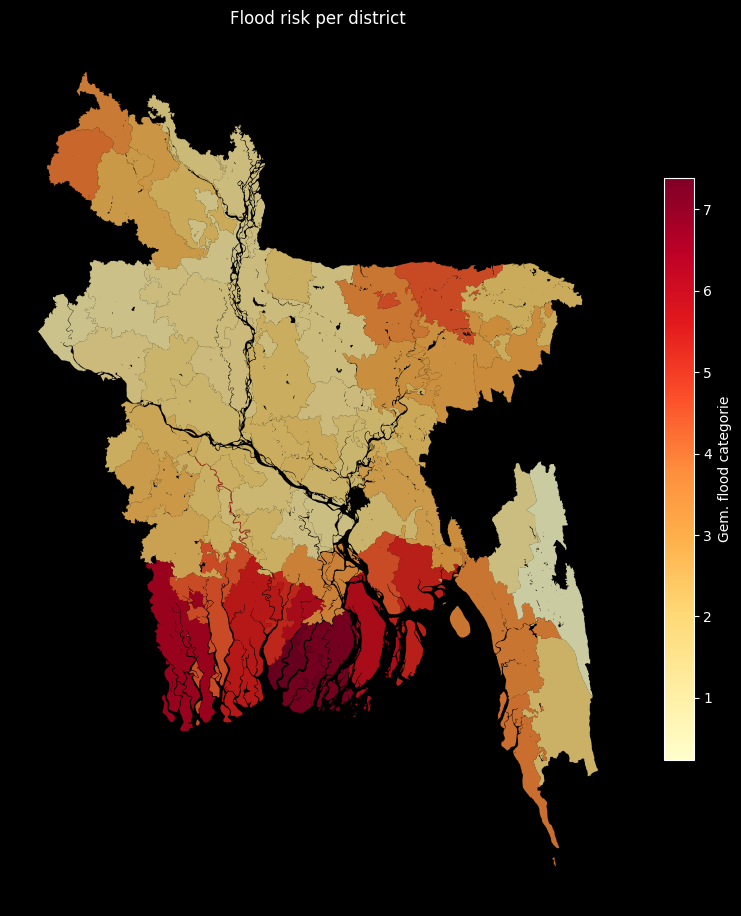

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt

floods = gpd.read_file("../data/flood shapefile/bgd_nhr_floods_sparsso.shp")

floods["geometry"] = floods["geometry"].buffer(0)
floods_dist = floods.dissolve(by="DISTNAME", aggfunc={"FLOODCAT": "mean"}).reset_index()

fig, ax = plt.subplots(figsize=(8, 10))

floods_dist.plot(ax=ax, column="FLOODCAT", cmap="YlOrRd",
                 legend=True, alpha=0.8,
                 legend_kwds={"label": "Gem. flood categorie", "shrink": 0.6})

ax.set_title("Flood risk per district")
ax.axis("off")
plt.tight_layout()
plt.show()

In [23]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# 1. Maak GeoDataFrame van roads (punten op basis van lat/lon)
gdf_roads = gpd.GeoDataFrame(
    df_roads_bridges,
    geometry=gpd.points_from_xy(df_roads_bridges["lon"], df_roads_bridges["lat"]),
    crs="EPSG:4326"
)

# 2. Laad flood shapefile en bereken mean FLOODCAT per district
floods = gpd.read_file("../data/flood shapefile/bgd_nhr_floods_sparsso.shp")
floods["geometry"] = floods["geometry"].buffer(0)
floods_dist = floods.dissolve(by="DISTNAME", aggfunc={"FLOODCAT": "mean"}).reset_index()
floods_dist = floods_dist.set_crs("EPSG:4326", allow_override=True)

# 3. Spatial join: what district is nearest to the given LRP
gdf_roads_proj = gdf_roads.to_crs("EPSG:32645")
floods_dist_proj = floods_dist.to_crs("EPSG:32645")

gdf_floods_joined = gpd.sjoin_nearest(
    gdf_roads_proj,
    floods_dist_proj[["DISTNAME", "FLOODCAT", "geometry"]],
    how="left"
)

# 4. Resultaat
gdf_floods_joined[["road", "lrp", "lat", "lon", "DISTNAME", "FLOODCAT"]].head(5)

,road,lrp,lat,lon,DISTNAME,FLOODCAT
0,N1,LRPS,23.706028,90.443333,Dhaka,2.105263
1,N1,LRPSa,23.702917,90.450417,Dhaka,2.105263
2,N1,LRPSb,23.702778,90.450472,Dhaka,2.105263
3,N1,LRP001,23.702139,90.451972,Dhaka,2.105263
4,N1,LRP002,23.697889,90.460583,Dhaka,2.105263


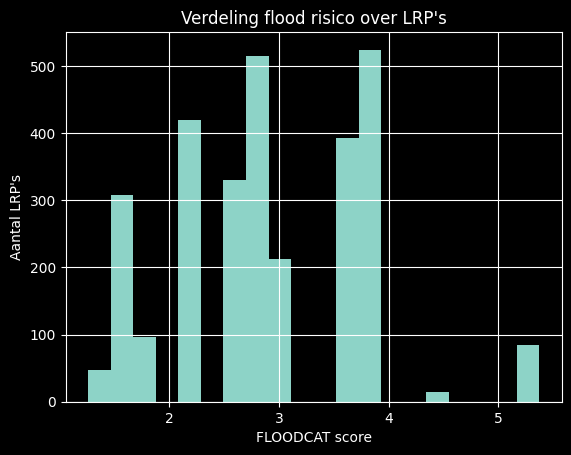

In [24]:
import matplotlib.pyplot as plt

gdf_floods_joined["FLOODCAT"].hist(bins=20)
plt.xlabel("FLOODCAT score")
plt.ylabel("Aantal LRP's")
plt.title("Verdeling flood risico over LRP's")
plt.show()

In [25]:
gdf_floods_joined[gdf_floods_joined["type_simple"] == "Bridge"].groupby("DISTNAME")["FLOODCAT"].mean().sort_values(ascending=False)

DISTNAME
Noakhali         5.371429
Sunamganj        4.505495
Cox'S Bazar      3.840580
Chittagong       3.642857
Maulvibazar      2.971429
Feni             2.937500
Kishoreganj      2.884058
Habiganj         2.843750
Comilla          2.553030
Brahamanbaria    2.168421
Sylhet           2.098039
Bandarban        1.818182
Munshiganj       1.741379
Narsingdi        1.666667
Narayanganj      1.583333
Gazipur          1.259259
Name: FLOODCAT, dtype: float64

## Merge with Earthquake

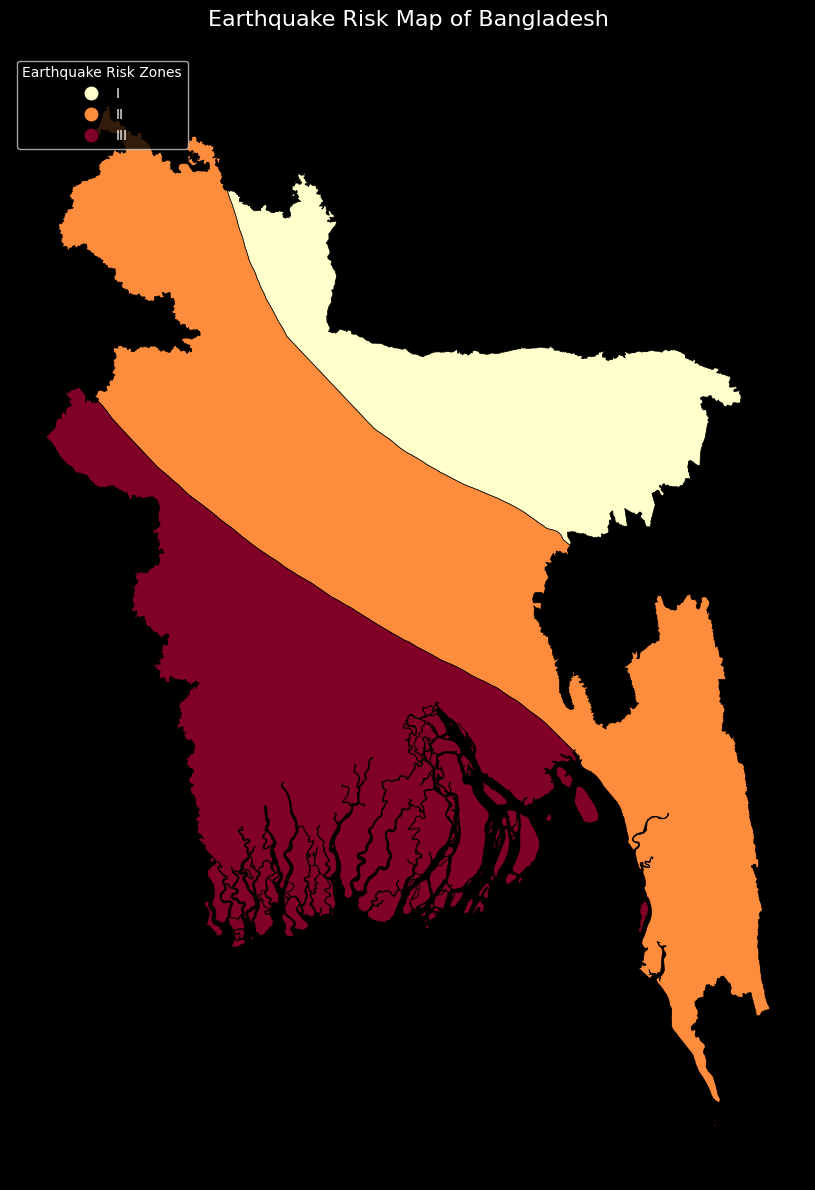

In [26]:
import matplotlib.pyplot as plt
import geopandas as gpd

# 1. Load the shapefile
# Ensure .shp, .dbf, and .shx files are in the same directory
file_path = "../data/earthquake shapefile/bgd_nhr_earthquake_sparsso.shp"

try:
    gdf = gpd.read_file(file_path)
except Exception as e:
    print(f"Error loading file: {e}")
    # If the file is not found, ensure you've uploaded it to the working directory
    exit()

# 2. Setup the visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

# Define colors for the zones based on your data:
# 1I (High), 2II (Moderate), 3III (Low)
color_dict = {
    '1I': '#d73027',    # Red
    '2II': '#fdae61',   # Orange
    '3III': '#fee08b'   # Yellow
}

# 3. Plotting
gdf.plot(
    column='ZONE',
    ax=ax,
    legend=True,
    categorical=True,
    cmap='YlOrRd', # Yellow-Orange-Red gradient
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'title': "Earthquake Risk Zones", 'loc': 'upper left'}
)

# 4. Add titles and clean up
ax.set_title("Earthquake Risk Map of Bangladesh", fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [27]:
import geopandas as gpd
eq = gpd.read_file("../data/earthquake shapefile/bgd_nhr_earthquake_sparsso.shp")
print(eq.columns.tolist())

['AREA', 'PERIMETER', 'EARTHQUF_', 'EARTHQUF_I', 'ZONE', 'CO_EFFIC', 'geometry']


In [31]:
import geopandas as gpd
import pandas as pd

# 1. Maak GeoDataFrame van roads (punten op basis van lat/lon)
gdf_roads = gpd.GeoDataFrame(
    df_roads_bridges,
    geometry=gpd.points_from_xy(df_roads_bridges["lon"], df_roads_bridges["lat"]),
    crs="EPSG:4326"
)

# 2. Laad earthquake shapefile
earthquakes = gpd.read_file("../data/earthquake shapefile/bgd_nhr_earthquake_sparsso.shp")
earthquakes["geometry"] = earthquakes["geometry"].buffer(0)
earthquakes = earthquakes.set_crs("EPSG:4326", allow_override=True)

# 3. Spatial join: welke zone hoort bij elk LRP-punt?
gdf_roads_proj = gdf_roads.to_crs("EPSG:32645")
earthquakes_proj = earthquakes.to_crs("EPSG:32645")

gdf_earthquake_joined = gpd.sjoin_nearest(
    gdf_roads_proj,
    earthquakes_proj[["ZONE", "CO_EFFIC", "geometry"]],
    how="left"
)

# 4. Resultaat
# gdf_earthquake_joined[["road", "lrp", "lat", "lon", "ZONE", "CO_EFFIC"]].head(50)
gdf_earthquake_joined

,road,chainage,lrp,lat,lon,gap,type,name,id,length,...,LRPName,length_bmms,condition,name_bmms,target_road,is_junction,geometry,index_right,ZONE,CO_EFFIC
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...,0,0.0,...,NaN,NaN,NaN,NaN,NaN,False,POINT (851160.096 2625926.149),0,II,0.05g
1,N1,0.814,LRPSa,23.702917,90.450417,NaN,Culvert,Box Culvert,1,814.0,...,LRPSa,15.641024,D,Kashinathpur Bridge,NaN,False,POINT (851891.464 2625598.802),0,II,0.05g
2,N1,0.822,LRPSb,23.702778,90.450472,NaN,CrossRoad,Intersection with Z1101,2,8.0,...,LRPSb,12.752515,D,TANARI BOTTOLA CULVERT,NaN,True,POINT (851897.502 2625583.543),0,II,0.05g
3,N1,1.000,LRP001,23.702139,90.451972,NaN,KmPost,Km post missing,3,178.0,...,NaN,NaN,NaN,NaN,NaN,False,POINT (852052.324 2625516.435),0,II,0.05g
4,N1,2.000,LRP002,23.697889,90.460583,NaN,KmPost,Km post missing,4,1000.0,...,NaN,NaN,NaN,NaN,NaN,False,POINT (852942.713 2625066.64),0,II,0.05g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2938,N207,65.685,LRP066,24.606611,91.679944,NaN,KmPost,Sylhet 40 km,3507,970.0,...,NaN,NaN,NaN,NaN,NaN,False,POINT (974091.002 2729463.613),2,I,0.08g
2939,N207,66.091,LRP066a,24.609556,91.678027,NaN,Culvert,Box Culvert,3508,406.0,...,LRP066a,35.591667,D,MUNDABAD BOX CULVERT,NaN,False,POINT (973885.417 2729783.724),2,I,0.08g
2940,N207,66.685,LRP067,24.615056,91.677222,NaN,KmPost,Sylhet 39 km,3509,594.0,...,NaN,NaN,NaN,NaN,NaN,False,POINT (973782.904 2730391.251),2,I,0.08g
2941,N207,67.635,LRP068,24.623277,91.678166,NaN,KmPost,Sylhet 38 km,3510,950.0,...,NaN,NaN,NaN,NaN,NaN,False,POINT (973847.607 2731306.821),2,I,0.08g
